# Pasos 6 y 7 — Entrenamiento y Simulación con Datos No Vistos
**Random Forest (scikit-learn) + RNA (TensorFlow/Keras)**


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os, joblib, warnings

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, cross_val_score

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks

warnings.filterwarnings('ignore')
tf.get_logger().setLevel('ERROR')

BASE_DIR  = os.path.abspath('..')
PROCESSED = os.path.join(BASE_DIR, 'dataset', 'processed')
MODELS    = os.path.join(BASE_DIR, 'models')
FIGURES   = os.path.join(BASE_DIR, 'docs', 'figures')

X_train = np.load(os.path.join(PROCESSED, 'X_train.npy'))
X_val   = np.load(os.path.join(PROCESSED, 'X_val.npy'))
X_test  = np.load(os.path.join(PROCESSED, 'X_test.npy'))
y_train = np.load(os.path.join(PROCESSED, 'y_train.npy'))
y_val   = np.load(os.path.join(PROCESSED, 'y_val.npy'))
y_test  = np.load(os.path.join(PROCESSED, 'y_test.npy'))
le      = joblib.load(os.path.join(MODELS, 'label_encoder.pkl'))

N_CLASES = len(le.classes_)
print(f'Clases: {list(le.classes_)}')
print(f'Train: {X_train.shape} | Val: {X_val.shape} | Test: {X_test.shape}')

Clases: ['Alerta', 'Contaminada', 'Optima']
Train: (10506, 3) | Val: (909, 3) | Test: (909, 3)


## 6A — Random Forest con GridSearchCV

In [2]:
param_grid_rf = {
    'n_estimators':      [100, 200, 300],
    'max_depth':         [None, 10, 20],
    'min_samples_split': [2, 5],
    'max_features':      ['sqrt', 'log2']
}

rf_base = RandomForestClassifier(random_state=42, n_jobs=-1, class_weight='balanced')
grid_rf  = GridSearchCV(rf_base, param_grid_rf, cv=5,
                        scoring='f1_weighted', n_jobs=-1, verbose=1)
grid_rf.fit(X_train, y_train)

print(f'\nMejores hiperparámetros RF: {grid_rf.best_params_}')
print(f'F1-score validación cruzada: {grid_rf.best_score_:.4f}')

mejor_rf = grid_rf.best_estimator_
joblib.dump(mejor_rf, os.path.join(MODELS, 'random_forest.pkl'))
print('Modelo RF guardado en models/random_forest.pkl')

Fitting 5 folds for each of 36 candidates, totalling 180 fits

Mejores hiperparámetros RF: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 200}
F1-score validación cruzada: 0.9973
Modelo RF guardado en models/random_forest.pkl


## 6B — Red Neuronal Artificial (RNA)

In [3]:
def construir_rna(n_entradas=3, n_clases=3,
                  capas=[64, 32], dropout=0.3, lr=0.001):
    """Arquitectura RNA para clasificación multiclase de calidad del agua."""
    modelo = keras.Sequential(name='RNA_CalidadAgua')
    modelo.add(layers.Input(shape=(n_entradas,)))

    for i, neuronas in enumerate(capas):
        modelo.add(layers.Dense(neuronas, activation='relu', name=f'dense_{i+1}'))
        modelo.add(layers.BatchNormalization(name=f'bn_{i+1}'))
        modelo.add(layers.Dropout(dropout, name=f'dropout_{i+1}'))

    modelo.add(layers.Dense(n_clases, activation='softmax', name='salida'))

    modelo.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return modelo

rna = construir_rna(n_clases=N_CLASES)
rna.summary()

Model: "RNA_CalidadAgua"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape        ┃    Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━┩
│ dense_1 (Dense)           │ (None, 64)          │        256 │
├───────────────────────────┼─────────────────────┼────────────┤
│ bn_1 (BatchNormalization) │ (None, 64)          │        256 │
├───────────────────────────┼─────────────────────┼────────────┤
│ dropout_1 (Dropout)       │ (None, 64)          │          0 │
├───────────────────────────┼─────────────────────┼────────────┤
│ dense_2 (Dense)           │ (None, 32)          │      2,080 │
├───────────────────────────┼─────────────────────┼────────────┤
│ bn_2 (BatchNormalization) │ (None, 32)          │        128 │
├───────────────────────────┼─────────────────────┼────────────┤
│ dropout_2 (Dropout)       │ (None, 32)          │          0 │
├───────────────────────────┼─────────────────────┼────────────┤
│ salida (Dense)            │ (None, 3)           │         99 │
└───────────────────────────┴─────────────────────┴────────────┘

 Total params: 2,819 (11.01 KB)

 Trainable params: 2,627 (10.26 KB)

 Non-trainable params: 192 (768.00 B)

In [4]:
# Callbacks para control del entrenamiento
early_stop  = callbacks.EarlyStopping(
    monitor='val_loss', patience=20,
    restore_best_weights=True, verbose=1
)
reduce_lr   = callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5,
    patience=8, min_lr=1e-6, verbose=1
)
checkpoint  = callbacks.ModelCheckpoint(
    os.path.join(MODELS, 'rna_mejor.keras'),
    monitor='val_accuracy', save_best_only=True, verbose=1
)

historia = rna.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=200,
    batch_size=32,
    callbacks=[early_stop, reduce_lr, checkpoint],
    verbose=1
)

Epoch 1/200
327/329 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5878 - loss: 0.8869
Epoch 1: val_accuracy improved from None to 0.81628, saving model to C:\Users\GABRIEL POLO\OneDrive\Escritorio\ingenieria\universidad\octavo semestre\inteligencia artificial\proyecto de aula\sistema de monitoreo de calidad del agua\models\rna_mejor.keras

Epoch 1: finished saving model to C:\Users\GABRIEL POLO\OneDrive\Escritorio\ingenieria\universidad\octavo semestre\inteligencia artificial\proyecto de aula\sistema de monitoreo de calidad del agua\models\rna_mejor.keras
329/329 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.6453 - loss: 0.7405 - val_accuracy: 0.8163 - val_loss: 0.4222 - learning_rate: 0.0010
Epoch 2/200
317/329 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7627 - loss: 0.5035
Epoch 2: val_accuracy improved from 0.81628 to 0.90869, saving model to C:\Users\GABRIEL POLO\OneDrive\Escritorio\ingenieria\universidad\octavo semestre\inteligencia artificial\proyecto de aula\sistema de moni

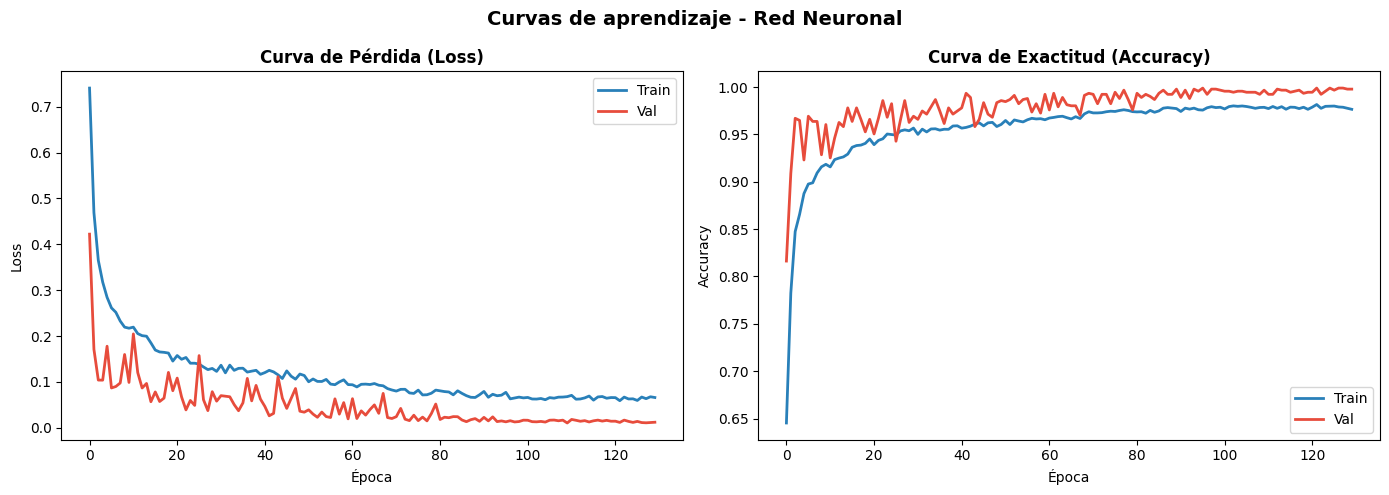

Entrenamiento completado en 130 épocas.


In [5]:
# Curvas de aprendizaje
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(historia.history['loss'],     label='Train', color='#2980B9', linewidth=2)
axes[0].plot(historia.history['val_loss'], label='Val',   color='#E74C3C', linewidth=2)
axes[0].set_title('Curva de Pérdida (Loss)', fontweight='bold')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(historia.history['accuracy'],     label='Train', color='#2980B9', linewidth=2)
axes[1].plot(historia.history['val_accuracy'], label='Val',   color='#E74C3C', linewidth=2)
axes[1].set_title('Curva de Exactitud (Accuracy)', fontweight='bold')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.suptitle('Curvas de aprendizaje - Red Neuronal', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES, '05_curvas_aprendizaje.png'), dpi=150)
plt.show()
print(f'Entrenamiento completado en {len(historia.history["loss"])} épocas.')

## 7 — Simulación con datos del conjunto de PRUEBA (no vistos)

In [6]:
# Cargar mejor modelo guardado
mejor_rna = keras.models.load_model(os.path.join(MODELS, 'rna_mejor.keras'))

# Predicciones en el conjunto de prueba
y_pred_rf   = mejor_rf.predict(X_test)
y_pred_rna  = np.argmax(mejor_rna.predict(X_test, verbose=0), axis=1)

print(f'Evaluación en conjunto de PRUEBA ({len(X_test):,} muestras):')
from sklearn.metrics import accuracy_score
acc_rf  = accuracy_score(y_test, y_pred_rf)
acc_rna = accuracy_score(y_test, y_pred_rna)
print(f'  Random Forest → Accuracy: {acc_rf:.4f} ({acc_rf*100:.1f}%)')
print(f'  RNA           → Accuracy: {acc_rna:.4f} ({acc_rna*100:.1f}%)')

Evaluación en conjunto de PRUEBA (909 muestras):
  Random Forest → Accuracy: 0.9978 (99.8%)
  RNA           → Accuracy: 0.9989 (99.9%)


In [7]:
# Simulación con datos nuevos (como llegarían del hardware ESP32)
scaler = joblib.load(os.path.join(MODELS, 'scaler.pkl'))

datos_hardware = np.array([
    [7.1,  2.3, 21.5],   # Muestra típica: agua óptima
    [6.2,  6.5, 27.0],   # pH bajo + turbidez alta: alerta
    [4.5, 18.0, 34.0],   # pH muy ácido + turbidez muy alta: contaminada
    [8.9,  4.8, 24.0],   # pH alto: alerta
    [7.0,  3.0, 22.0],   # Normal: óptima
])

datos_norm   = scaler.transform(datos_hardware)
pred_rf      = le.inverse_transform(mejor_rf.predict(datos_norm))
proba_rna    = mejor_rna.predict(datos_norm, verbose=0)
pred_rna     = le.inverse_transform(np.argmax(proba_rna, axis=1))

print('=== SIMULACIÓN CON DATOS DEL SENSOR ===')
print(f'{"pH":>6} {"Turbid":>8} {"Temp":>7} │ {"Random Forest":>14} │ {"RNA":>14}')
print('─' * 60)
for i, (d, prf, prna) in enumerate(zip(datos_hardware, pred_rf, pred_rna)):
    print(f'{d[0]:6.1f} {d[1]:8.1f} {d[2]:7.1f} │ {prf:>14} │ {prna:>14}')

=== SIMULACIÓN CON DATOS DEL SENSOR ===
    pH   Turbid    Temp │  Random Forest │            RNA
────────────────────────────────────────────────────────────
   7.1      2.3    21.5 │         Optima │         Optima
   6.2      6.5    27.0 │         Alerta │         Alerta
   4.5     18.0    34.0 │    Contaminada │    Contaminada
   8.9      4.8    24.0 │         Alerta │         Alerta
   7.0      3.0    22.0 │         Optima │         Optima
